# 01. Text Preprocessing and TF-IDF with scikit-learn

This notebook is organized as a practical workflow:
1. Load a larger dataset from `data/01_data`.
2. Build and inspect text preprocessing.
3. Train a TF-IDF similarity router with `scikit-learn`.
4. Evaluate performance.
5. Return production-style predictions for new tickets.


## 1. What you will build

- A full text preprocessing pipeline (normalization, tokenization, stopword removal, lemmatization).
- A TF-IDF similarity router for support ticket triage.
- A reusable inference function that returns label, confidence, and nearest examples.


## 2. When to use this in real companies

Use this approach when you need a fast, transparent baseline for ticket routing, customer operations, or queue automation. It is ideal for teams that need low latency, interpretable predictions, and simple retraining cycles before moving to larger transformer models.


## 3. Business goal

Route support tickets into operational queues (`billing`, `technical`, `shipping`, `account_access`) with a baseline that is fast, interpretable, and easy to maintain.


## 4. Imports and setup


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

## 5. Load the dataset

Primary file: `data/01_data/support_tickets_en.csv`.
A fallback path is included for notebook execution from different working directories.


In [2]:
DATA_PATH = Path("../data/01_data/support_tickets_en.csv")
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["raw_text", "label"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Classes: {df['label'].nunique()}")

df.head()

Rows: 1,000
Classes: 4


,ticket_id,raw_text,label
0,TCK-00001,Good morning: My password is rejected even aft...,account_access
1,TCK-00002,Quick request: I cannot complete email verific...,account_access
2,TCK-00003,"Good morning, I am reporting this issue: File ...",technical
3,TCK-00004,Need assistance: I received the wrong product....,shipping
4,TCK-00005,"Good morning, The invoice total is incorrect. ...",billing


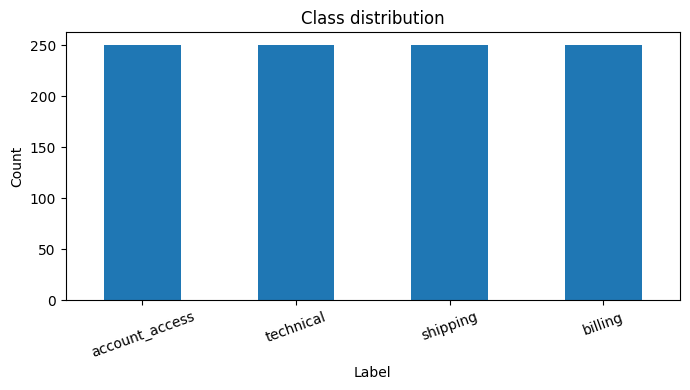

In [3]:
ax = df["label"].value_counts().plot(kind="bar", figsize=(7, 4), title="Class distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Preprocessing

The preprocessing pipeline is now explicit and complete:
- normalization,
- tokenization,
- stopword removal,
- lemmatization.

The reusable function is named `preproceso(...)` and is used both in training and inference.
N-gram features are generated later by `TfidfVectorizer` via `ngram_range=(1, 2)`.


In [4]:
STOPWORDS = set(ENGLISH_STOP_WORDS)

try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError as exc:
    raise OSError("Run: python -m spacy download en_core_web_sm") from exc


def normalize_text(text: str) -> str:
    """Normalize raw text by lowercasing, removing punctuation, and collapsing spaces."""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_text(normalized_text: str):
    """Tokenize normalized text with spaCy and keep alphabetic tokens only."""
    doc = nlp(normalized_text)
    return [token for token in doc if token.is_alpha]


def remove_stopwords(tokens):
    """Remove tokens whose surface form is in scikit-learn English stopwords."""
    return [token for token in tokens if token.text not in STOPWORDS]


def lemmatize_tokens(tokens):
    """Convert tokens to lemmas and filter empty/pronoun placeholder lemmas."""
    lemmas = []
    for token in tokens:
        lemma = token.lemma_.lower().strip()
        if lemma and lemma != "-pron-":
            lemmas.append(lemma)
    return lemmas


def preproceso(text: str) -> str:
    """Run the full preprocessing pipeline and return a whitespace-joined lemma string."""
    normalized = normalize_text(text)
    token_objs = tokenize_text(normalized)
    token_objs = remove_stopwords(token_objs)
    lemmas = lemmatize_tokens(token_objs)
    return " ".join(lemmas)


def preprocessing_steps(text: str):
    """Return intermediate artifacts for each preprocessing stage for inspection/debugging."""
    normalized = normalize_text(text)
    token_objs = tokenize_text(normalized)
    tokens = [token.text for token in token_objs]

    token_objs_no_stop = remove_stopwords(token_objs)
    tokens_no_stop = [token.text for token in token_objs_no_stop]

    lemmas = lemmatize_tokens(token_objs_no_stop)

    return {
        "normalized": normalized,
        "tokens": tokens,
        "tokens_without_stopwords": tokens_no_stop,
        "lemmas": lemmas,
    }

In [5]:
sample_text = df.loc[0, "raw_text"]
steps = preprocessing_steps(sample_text)

step_by_step = pd.DataFrame(
    {
        "step": [
            "raw_text",
            "normalized",
            "tokenized",
            "without_stopwords",
            "lemmatized",
        ],
        "value": [
            sample_text,
            steps["normalized"],
            ", ".join(steps["tokens"][:20]),
            ", ".join(steps["tokens_without_stopwords"][:20]),
            ", ".join(steps["lemmas"][:20]),
        ],
    }
)
step_by_step

,step,value
0,raw_text,Good morning: My password is rejected even aft...
1,normalized,good morning my password is rejected even afte...
2,tokenized,"good, morning, my, password, is, rejected, eve..."
3,without_stopwords,"good, morning, password, rejected, reset, open..."
4,lemmatized,"good, morning, password, reject, reset, open, ..."


## 7. Train/test split

We split before vectorization to avoid data leakage.


In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")

Train rows: 800
Test rows:  200


In [7]:
train_df.head(3)

,ticket_id,raw_text,label
0,TCK-00828,"Good afternoon, I am reporting this issue: The...",shipping
1,TCK-00941,"Please help, I am reporting this issue: I was ...",billing
2,TCK-00470,"Urgent, The courier asked for an unexpected fe...",shipping


In [8]:
test_df.head(3)

,ticket_id,raw_text,label
0,TCK-00101,"Hello support, The courier asked for an unexpe...",shipping
1,TCK-00571,"Quick request, I am reporting this issue: The ...",billing
2,TCK-00733,"Urgent, I am reporting this issue: Search retu...",technical


## 8. `TfidfVectorizer` configuration explained

Key parameters used below:
- `preprocessor=preproceso`: runs our full custom preprocessing pipeline (normalization, tokenization, stopword removal, lemmatization).
- `tokenizer=str.split`: splits the preprocessed lemma string into tokens.
- `token_pattern=None`: required when a custom tokenizer is provided, so scikit-learn does not apply its default regex tokenizer.
- `stop_words=None`: stopwords are already removed inside `preproceso` using `ENGLISH_STOP_WORDS` from scikit-learn.
- `ngram_range=(1, 2)`: keeps unigrams and bigrams as TF-IDF features.
- `min_df=2`: ignores very rare terms (appearing in fewer than 2 training documents).
- `max_df=0.95`: ignores overly frequent terms (appearing in more than 95% of training documents).
- `sublinear_tf=True`: replaces raw term frequency with `1 + log(tf)` to reduce the effect of repeated words.


In [9]:
vectorizer = TfidfVectorizer(
    preprocessor=preproceso,
    tokenizer=str.split,
    token_pattern=None,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_df["raw_text"])
# fit_transform does two things on the training set:
# 1. fit: learns the vocabulary and computes the IDF (inverse document frequency) values from train data.
# 2. transform: converts each training document into a TF-IDF feature vector using that learned vocabulary.
# The result is a sparse matrix where:
# - rows = training documents
# - columns = vocabulary terms (unigrams and bigrams)
# - values = TF-IDF scores

X_test = vectorizer.transform(test_df["raw_text"])
# transform applies the already learned training vocabulary and IDF values to the test set.
# It does NOT learn anything new from test data.
# It only converts test documents into TF-IDF vectors using the same feature space as X_train.
# This is important to avoid data leakage and keep train/test representations consistent.

print(f"Train matrix shape: {X_train.shape}")
print(f"Test matrix shape:  {X_test.shape}")
print(f"Vocabulary size:    {len(vectorizer.get_feature_names_out())}")

Train matrix shape: (800, 842)
Test matrix shape:  (200, 842)
Vocabulary size:    842


## 9. Training logic: similarity-based routing

For each test ticket:
1. compute cosine similarity against all training tickets,
2. pick the closest training example,
3. inherit its label.


In [10]:
sim_matrix = cosine_similarity(X_test, X_train)
best_idx = sim_matrix.argmax(axis=1)
best_sim = sim_matrix.max(axis=1)

pred_labels = train_df.iloc[best_idx]["label"].to_numpy()

results = test_df[["ticket_id", "raw_text", "label"]].copy()
results["predicted_label"] = pred_labels
results["similarity"] = best_sim.round(4)
results.head(10)

,ticket_id,raw_text,label,predicted_label,similarity
0,TCK-00101,"Hello support, The courier asked for an unexpe...",shipping,shipping,0.6406
1,TCK-00571,"Quick request, I am reporting this issue: The ...",billing,billing,0.7074
2,TCK-00733,"Urgent, I am reporting this issue: Search retu...",technical,technical,0.6261
3,TCK-00775,"Please help, I am reporting this issue: SSO lo...",account_access,account_access,0.6646
4,TCK-00524,"Good morning, The website is extremely slow. S...",technical,technical,0.5728
5,TCK-00381,Good morning: The courier delivered to the wro...,shipping,shipping,0.6749
6,TCK-00003,"Good morning, I am reporting this issue: File ...",technical,technical,0.8272
7,TCK-00447,"Quick request, I need an updated invoice with ...",billing,billing,0.6880
8,TCK-00573,"Good morning, I am reporting this issue: I was...",billing,billing,0.9082
9,TCK-00601,"Good afternoon, I get logged out immediately. ...",account_access,account_access,0.5594


## 10. Evaluation


Accuracy: 1.000

Classification report:

                precision    recall  f1-score   support

account_access      1.000     1.000     1.000        50
       billing      1.000     1.000     1.000        50
      shipping      1.000     1.000     1.000        50
     technical      1.000     1.000     1.000        50

      accuracy                          1.000       200
     macro avg      1.000     1.000     1.000       200
  weighted avg      1.000     1.000     1.000       200



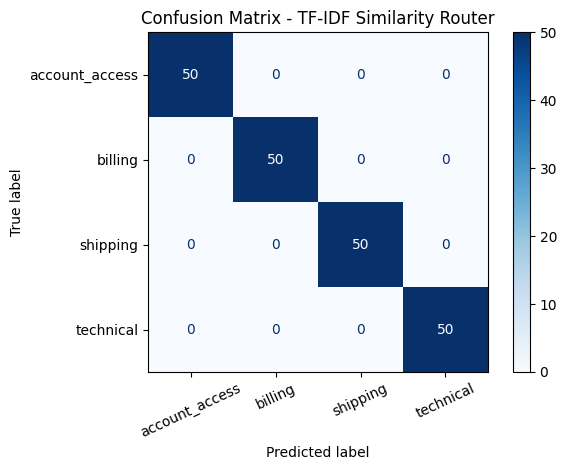

In [11]:
acc = accuracy_score(results["label"], results["predicted_label"])
print(f"Accuracy: {acc:.3f}")
print("\nClassification report:\n")
print(classification_report(results["label"], results["predicted_label"], digits=3))

ConfusionMatrixDisplay.from_predictions(
    results["label"],
    results["predicted_label"],
    cmap="Blues",
    xticks_rotation=25,
)
plt.title("Confusion Matrix - TF-IDF Similarity Router")
plt.tight_layout()
plt.show()

## 11. Inference function: returning a production-style response

The function returns:
- `predicted_label`
- `confidence` (based on aggregated similarity over top neighbors)
- `neighbors` as evidence for debugging/traceability.


In [12]:
def route_ticket(ticket_text: str, top_k: int = 5):
    """Route a new ticket using TF-IDF similarity over historical training tickets.

    Parameters
    ----------
    ticket_text : str
        Incoming support message.
    top_k : int, default=5
        Number of nearest neighbors considered for the final decision.

    Returns
    -------
    payload : dict
        Prediction payload with label and confidence.
    neighbors : pd.DataFrame
        Top similar training tickets used as evidence.
    """
    if top_k < 1:
        raise ValueError("top_k must be >= 1")

    query_vec = vectorizer.transform([ticket_text])
    sims = cosine_similarity(query_vec, X_train).ravel()

    top_k = min(top_k, len(train_df))
    top_idx = sims.argsort()[::-1][:top_k]

    neighbors = train_df.loc[top_idx, ["ticket_id", "raw_text", "label"]].copy()
    neighbors["similarity"] = sims[top_idx]
    neighbors = neighbors.sort_values("similarity", ascending=False).reset_index(drop=True)

    label_weights = neighbors.groupby("label", as_index=True)["similarity"].sum().sort_values(ascending=False)
    predicted_label = label_weights.index[0]
    confidence = float(label_weights.iloc[0] / label_weights.sum()) if label_weights.sum() > 0 else 0.0

    payload = {
        "input_text": ticket_text,
        "predicted_label": predicted_label,
        "confidence": round(confidence, 4),
        "top_k": top_k,
    }
    return payload, neighbors

In [13]:
new_ticket = "I cannot sign in and the two-factor code never arrives for my account"
payload, evidence = route_ticket(new_ticket, top_k=5)
payload

{'input_text': 'I cannot sign in and the two-factor code never arrives for my account',
 'predicted_label': 'account_access',
 'confidence': 1.0,
 'top_k': 5}

In [14]:
evidence

,ticket_id,raw_text,label,similarity
0,TCK-00495,"Need assistance, The two-factor code never arr...",account_access,0.468056
1,TCK-00248,"Urgent, The two-factor code never arrives. Rep...",account_access,0.466097
2,TCK-00148,"Urgent, The two-factor code never arrives. Sen...",account_access,0.456240
3,TCK-00491,"Please help, The two-factor code never arrives...",account_access,0.449078
4,TCK-00933,Quick request: The two-factor code never arriv...,account_access,0.446449


## 12. Summary

- The notebook now includes full preprocessing steps: normalization, tokenization, stopword removal, and lemmatization.
- The reusable function is `preproceso(...)` and it is applied consistently in training and inference.
- Stopwords come from scikit-learn (`ENGLISH_STOP_WORDS`) instead of a manual dictionary.
- N-grams are generated by `TfidfVectorizer` (`ngram_range=(1, 2)`), not by manual preprocessing.
- `TfidfVectorizer` parameters are documented so each preprocessing and feature choice is explicit.
